<a href="https://colab.research.google.com/github/carlosgmontoya/pytorch_JE/blob/main/John_Elder_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.npz'):
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/dataset_swell_completo_v2.npz
/content/drive/MyDrive/Colab Notebooks/dataset_amarillo_final.npz
/content/drive/MyDrive/Colab Notebooks/dataset_filtrado.npz
/content/drive/MyDrive/Colab Notebooks/dataset_filtrado_v2.npz
/content/drive/MyDrive/Colab Notebooks/swell_700hz_clean.npz
/content/drive/MyDrive/Colab Notebooks/dataset_wesad.npz


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando WESAD...
Shape: (3320, 1, 7000)
Distribución — Normal:2320  Estrés:1000
Sujetos únicos: [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17]

Train: 2325  Val: 497  Test: 498

Dispositivo : cuda
Parámetros  : 702,466
Pesos clases: Normal=0.3011  Estrés=0.6989

Época 001 | LR 0.001000 ← mejor  [ES: 0/15]
  Loss      → Train: 0.6048  Val: 0.5315
  Acc: 0.7746 | Balanced Acc: 0.7667 | F1-Macro: 0.7482
  Sens: 0.7467 | Spec: 0.7867 | Prec: 0.6022

Época 002 | LR 0.001000  [ES: 1/15]
  Loss      → Train: 0.4894  Val: 0.5535
  Acc: 0.6901 | Balanced Acc: 0.7402 | F1-Macro: 0.6813
  Sens: 0.8667 | Spec: 0.6138 | Prec: 0.4924

Época 003 | LR 0.001000 ← mejor  [ES: 0/15]
  Loss      → Train: 0.4396  Val: 0.4216
  Acc: 0.8431 | Balanced Acc: 0.8384 | F1-Macro: 0.8220
  Sens: 0.8267 | Spec: 0.8501 | Prec: 0.7045

Época 004 | LR 0.001000 ← mejor  [ES: 0/15]
  Loss    

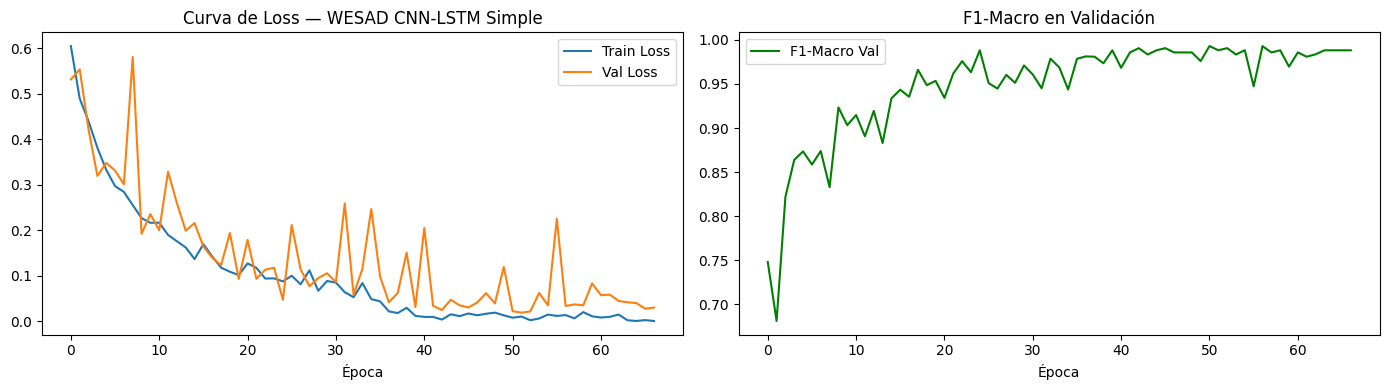


  RESULTADOS EN TEST — WESAD CNN-LSTM Simple
  Acc          : 0.9839
  Balanced Acc : 0.9828
  F1-Macro     : 0.9810
  Sensibilidad : 0.9800
  Especificidad: 0.9856
  Precisión    : 0.9671

 Modelo  : /content/drive/MyDrive/Colab Notebooks/modelos_wesad/wesad_simple_cnnlstm.pth
 Curvas  : /content/drive/MyDrive/Colab Notebooks/modelos_wesad/curvas_wesad_simple.png


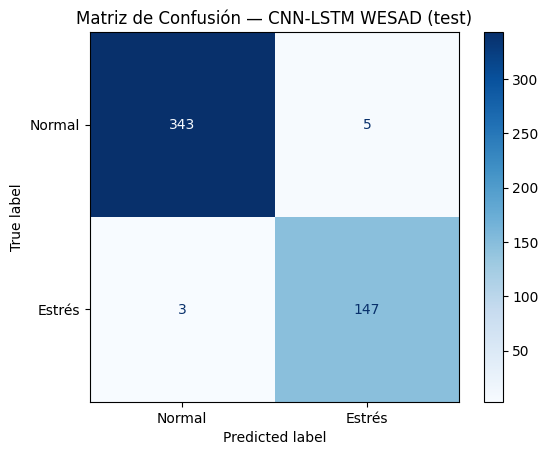

In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ==================== PATHS ====================
BASE_PATH   = '/content/drive/MyDrive/Colab Notebooks'
NPZ_PATH    = f'{BASE_PATH}/dataset_wesad.npz'
DIR_OUT     = f'{BASE_PATH}/modelos_wesad'
MODEL_PATH  = f'{DIR_OUT}/wesad_simple_cnnlstm.pth'
CURVAS_PATH = f'{DIR_OUT}/curvas_wesad_simple.png'
os.makedirs(DIR_OUT, exist_ok=True)

# ==========================================
# 1. MODELO CNN-LSTM SIMPLE
# ==========================================
class CNN_LSTM_Stress(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden=128, num_classes=2):
        super(CNN_LSTM_Stress, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(128)
        )
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, dropout=0.5, bidirectional=True
        )
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

# ==========================================
# 2. CARGA
# ==========================================
print("Cargando WESAD...")
datos  = np.load(NPZ_PATH, allow_pickle=True)
X_raw  = np.transpose(datos['x'], (0, 2, 1))  # (N, 1, 7000)
y_raw  = datos['binario'].astype(np.int64)
sujeto = datos['sujeto']

print(f"Shape: {X_raw.shape}")
print(f"Distribución — Normal:{(y_raw==0).sum()}  Estrés:{(y_raw==1).sum()}")
print(f"Sujetos únicos: {np.unique(sujeto)}")

# ==========================================
# 3. SPLIT 70 / 15 / 15
# ==========================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=42, stratify=y_raw
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# ==========================================
# 4. DATALOADERS
# ==========================================
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                  torch.tensor(y_train)),
    batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                  torch.tensor(y_val)),
    batch_size=32, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                  torch.tensor(y_test)),
    batch_size=32, shuffle=False
)

# ==========================================
# 5. CONFIGURACIÓN
# ==========================================
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = CNN_LSTM_Stress(num_classes=2).to(device)

conteos   = np.bincount(y_train, minlength=2)
pesos     = torch.tensor(1.0 / (conteos + 1e-8), dtype=torch.float32).to(device)
pesos     = pesos / pesos.sum()
criterion = nn.CrossEntropyLoss(weight=pesos)

optimizer    = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler    = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                     factor=0.5, patience=10)
PACIENCIA_ES = 15
contador_es  = 0

print(f"\nDispositivo : {device}")
print(f"Parámetros  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Pesos clases: Normal={pesos[0]:.4f}  Estrés={pesos[1]:.4f}\n")

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
best_val_loss = float('inf')
historial     = {'train_loss': [], 'val_loss': [], 'f1_macro': []}

for epoch in range(1, 101):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, all_preds, all_targets = 0, [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            val_loss += criterion(outputs, yb).item()
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    avg_train   = train_loss / len(train_loader)
    avg_val     = val_loss   / len(val_loader)
    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    acc   = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    prec  = precision_score(all_targets, all_preds, zero_division=0)
    rec   = recall_score(all_targets, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(all_targets, all_preds,
                                      labels=[0, 1]).ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0

    historial['train_loss'].append(avg_train)
    historial['val_loss'].append(avg_val)
    historial['f1_macro'].append(f1)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), MODEL_PATH)
        mejor_msg   = " ← mejor"
        contador_es = 0
    else:
        mejor_msg    = ""
        contador_es += 1

    scheduler.step(avg_val)
    lr = optimizer.param_groups[0]['lr']

    print(f"Época {epoch:03d} | LR {lr:.6f}{mejor_msg}  [ES: {contador_es}/{PACIENCIA_ES}]")
    print(f"  Loss      → Train: {avg_train:.4f}  Val: {avg_val:.4f}")
    print(f"  Acc: {acc:.4f} | Balanced Acc: {b_acc:.4f} | F1-Macro: {f1:.4f}")
    print(f"  Sens: {rec:.4f} | Spec: {spec:.4f} | Prec: {prec:.4f}\n")

    if contador_es >= PACIENCIA_ES:
        print(f"Early stopping en época {epoch}")
        break

# ==========================================
# 7. CURVAS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(historial['train_loss'], label='Train Loss')
axes[0].plot(historial['val_loss'],   label='Val Loss')
axes[0].set_title('Curva de Loss — WESAD CNN-LSTM Simple')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[1].plot(historial['f1_macro'], color='green', label='F1-Macro Val')
axes[1].set_title('F1-Macro en Validación')
axes[1].set_xlabel('Época')
axes[1].legend()
plt.tight_layout()
plt.savefig(CURVAS_PATH, dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 8. EVALUACIÓN FINAL EN TEST
# ==========================================
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        all_preds.extend(torch.argmax(model(xb), 1).cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

acc   = accuracy_score(all_targets, all_preds)
b_acc = balanced_accuracy_score(all_targets, all_preds)
f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
prec  = precision_score(all_targets, all_preds, zero_division=0)
rec   = recall_score(all_targets, all_preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(all_targets, all_preds, labels=[0, 1]).ravel()
spec  = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n{'='*55}")
print(f"  RESULTADOS EN TEST — WESAD CNN-LSTM Simple")
print(f"{'='*55}")
print(f"  Acc          : {acc:.4f}")
print(f"  Balanced Acc : {b_acc:.4f}")
print(f"  F1-Macro     : {f1:.4f}")
print(f"  Sensibilidad : {rec:.4f}")
print(f"  Especificidad: {spec:.4f}")
print(f"  Precisión    : {prec:.4f}")
print(f"{'='*55}")
print(f"\n Modelo  : {MODEL_PATH}")
print(f" Curvas  : {CURVAS_PATH}")

# ==========================================
# 9. MATRIZ DE CONFUSIÓN FINAL (TEST)
# ==========================================
cm   = confusion_matrix(all_targets, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Estrés'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — CNN-LSTM WESAD (test)')
plt.savefig(f'{DIR_OUT}/confusion_wesad_simple.png', dpi=150, bbox_inches='tight')
plt.show()


In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ==================== PATHS ====================
BASE_PATH  = '/content/drive/MyDrive/Colab Notebooks'
NPZ_PATH   = f'{BASE_PATH}/swell_700hz_clean.npz'
MODEL_WESAD = f'{BASE_PATH}/modelos_wesad/wesad_simple_cnnlstm.pth'
DIR_OUT    = f'{BASE_PATH}/modelos_swell_simple_tl'
os.makedirs(DIR_OUT, exist_ok=True)

# ==========================================
# 1. MODELO CNN-LSTM SIMPLE (igual que WESAD)
# ==========================================
class CNN_LSTM_Stress(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden=128, num_classes=2):
        super(CNN_LSTM_Stress, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(128)
        )
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, dropout=0.5, bidirectional=True
        )
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

# ==========================================
# 2. CARGA SWELL
# ==========================================
print("Cargando SWELL...")
datos   = np.load(NPZ_PATH, allow_pickle=True)
X_all   = datos['x']
y_all   = datos['binario'].astype(np.int64)
sujetos = datos['sujeto']

print(f"Shape: {X_all.shape}")
print(f"Distribución — Normal:{(y_all==0).sum()}  Estrés:{(y_all==1).sum()}")
print(f"Sujetos únicos: {np.unique(sujetos)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {device}")

# ==========================================
# 3. FINE-TUNING POR SUJETO
# ==========================================
EXCLUIDOS   = []
ids_sujetos = [s for s in np.unique(sujetos) if s not in EXCLUIDOS]
resultados  = []

print(f"Sujetos a procesar: {ids_sujetos}\n")

for sid in ids_sujetos:
    print(f"\n{'='*55}")
    print(f"  SUJETO {sid}")
    print(f"{'='*55}")

    mask  = sujetos == sid
    X_suj = X_all[mask]
    y_suj = y_all[mask]

    n_normal = (y_suj == 0).sum()
    n_estres = (y_suj == 1).sum()
    print(f"  Ventanas: {len(y_suj)}  |  Normal: {n_normal}  Estrés: {n_estres}")

    if n_normal < 10 or n_estres < 10:
        print(f"  OMITIDO: pocas ventanas")
        continue

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_suj, y_suj, test_size=0.15, random_state=42, stratify=y_suj
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )

    print(f"  Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train)),
        batch_size=32, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val)),
        batch_size=32, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                      torch.tensor(y_test)),
        batch_size=32, shuffle=False
    )

    # Cargar modelo pre-entrenado en WESAD
    model = CNN_LSTM_Stress(num_classes=2).to(device)
    model.load_state_dict(torch.load(MODEL_WESAD, weights_only=True))

    conteos   = np.bincount(y_train, minlength=2)
    pesos     = torch.tensor(1.0 / (conteos + 1e-8), dtype=torch.float32).to(device)
    pesos     = pesos / pesos.sum()
    criterion = nn.CrossEntropyLoss(weight=pesos)

    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5)
    PACIENCIA_ES  = 10
    contador_es   = 0
    best_val_loss = float('inf')
    modelo_path   = f'{DIR_OUT}/swell_simple_tl_s{sid:02d}.pth'

    for epoch in range(1, 51):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                val_loss += criterion(outputs, yb).item()
                all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
                all_targets.extend(yb.cpu().numpy())

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), modelo_path)
            contador_es = 0
            tag = " ← mejor"
        else:
            contador_es += 1
            tag = ""

        scheduler.step(avg_val)
        lr = optimizer.param_groups[0]['lr']
        print(f"  E{epoch:02d} | LR {lr:.6f} | Train:{avg_train:.4f} "
              f"Val:{avg_val:.4f} F1:{f1:.4f}{tag}  [ES:{contador_es}/{PACIENCIA_ES}]")

        if contador_es >= PACIENCIA_ES:
            print(f"  Early stopping en época {epoch}")
            break

    model.load_state_dict(torch.load(modelo_path, weights_only=True))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            all_preds.extend(torch.argmax(model(xb), 1).cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    acc   = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    prec  = precision_score(all_targets, all_preds, zero_division=0)
    rec   = recall_score(all_targets, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(all_targets, all_preds,
                                      labels=[0, 1]).ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n  TEST → Acc:{acc:.4f} | Bal.Acc:{b_acc:.4f} | F1:{f1:.4f}")
    print(f"         Sens:{rec:.4f} | Spec:{spec:.4f} | Prec:{prec:.4f}")

    resultados.append({
        'sujeto': sid, 'acc': acc, 'bal_acc': b_acc, 'f1': f1,
        'sens': rec, 'spec': spec, 'prec': prec, 'n_ventanas': len(y_suj)
    })

    del model
    torch.cuda.empty_cache()

# ==========================================
# 4. REPORTE GLOBAL
# ==========================================
print(f"\n{'='*70}")
print(f"  REPORTE GLOBAL — CNN-LSTM Simple + TL WESAD → SWELL")
print(f"{'='*70}")
print(f"{'Sujeto':>8} | {'Ventanas':>8} | {'Acc':>6} | {'Bal.Acc':>7} | "
      f"{'F1':>6} | {'Sens':>6} | {'Spec':>6}")
print("-" * 70)

for r in resultados:
    print(f"  {r['sujeto']:>4}   | {r['n_ventanas']:>8} | {r['acc']:.4f} | "
          f"{r['bal_acc']:.4f}  | {r['f1']:.4f} | {r['sens']:.4f} | {r['spec']:.4f}")

metrics = ['acc', 'bal_acc', 'f1', 'sens', 'spec']
print("-" * 70)
print(f"  {'MEDIA':>4}   | {'':>8} | ", end="")
print(" | ".join([f"{np.mean([r[m] for r in resultados]):.4f}" for m in metrics]))
print(f"  {'STD':>4}   | {'':>8} | ", end="")
print(" | ".join([f"{np.std([r[m] for r in resultados]):.4f}" for m in metrics]))
print(f"{'='*70}")

np.save(f'{DIR_OUT}/resultados.npy', resultados)
print(f"\n Resultados guardados en: {DIR_OUT}/resultados.npy")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando SWELL...
Shape: (17606, 1, 7000)
Distribución — Normal:6971  Estrés:10635
Sujetos únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 24 25]

Dispositivo: cuda
Sujetos a procesar: [np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12), np.int8(13), np.int8(14), np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(24), np.int8(25)]


  SUJETO 1
  Ventanas: 898  |  Normal: 352  Estrés: 546
  Train: 628  Val: 135  Test: 135
  E01 | LR 0.000100 | Train:3.2242 Val:4.0633 F1:0.3884 ← mejor  [ES:0/10]
  E02 | LR 0.000100 | Train:1.8224 Val:2.1689 F1:0.4428 ← mejor  [ES:0/10]
  E03 | LR 0.000100 | Train:1.3344 Val:0.9372 F1:0.6031 ← mejor  [ES:0/10]
  E04 | LR 0.000100 | Train:0.9186 Val

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ==================== PATHS ====================
BASE_PATH  = '/content/drive/MyDrive/Colab Notebooks'
NPZ_PATH   = f'{BASE_PATH}/swell_700hz_clean.npz'
MODEL_WESAD = f'{BASE_PATH}/modelos_wesad/wesad_simple_cnnlstm.pth'
DIR_OUT    = f'{BASE_PATH}/modelos_swell_simple_tl'
os.makedirs(DIR_OUT, exist_ok=True)

# ==========================================
# 1. MODELO CNN-LSTM SIMPLE (igual que WESAD)
# ==========================================
class CNN_LSTM_Stress(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden=128, num_classes=2):
        super(CNN_LSTM_Stress, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.AdaptiveAvgPool1d(128)
        )
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, dropout=0.5, bidirectional=True
        )
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

# ==========================================
# 2. CARGA SWELL
# ==========================================
print("Cargando SWELL...")
datos   = np.load(NPZ_PATH, allow_pickle=True)
X_all   = datos['x']
y_all   = datos['binario'].astype(np.int64)
sujetos = datos['sujeto']

print(f"Shape: {X_all.shape}")
print(f"Distribución — Normal:{(y_all==0).sum()}  Estrés:{(y_all==1).sum()}")
print(f"Sujetos únicos: {np.unique(sujetos)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {device}")

# ==========================================
# 3. FINE-TUNING POR SUJETO
# ==========================================
EXCLUIDOS   = []
ids_sujetos = [s for s in np.unique(sujetos) if s not in EXCLUIDOS]
resultados  = []

print(f"Sujetos a procesar: {ids_sujetos}\n")

for sid in ids_sujetos:
    print(f"\n{'='*55}")
    print(f"  SUJETO {sid}")
    print(f"{'='*55}")

    mask  = sujetos == sid
    X_suj = X_all[mask]
    y_suj = y_all[mask]

    n_normal = (y_suj == 0).sum()
    n_estres = (y_suj == 1).sum()
    print(f"  Ventanas: {len(y_suj)}  |  Normal: {n_normal}  Estrés: {n_estres}")

    if n_normal < 10 or n_estres < 10:
        print(f"  OMITIDO: pocas ventanas")
        continue

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_suj, y_suj, test_size=0.15, random_state=42, stratify=y_suj
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )

    print(f"  Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train)),
        batch_size=32, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val)),
        batch_size=32, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                      torch.tensor(y_test)),
        batch_size=32, shuffle=False
    )

    # Cargar modelo pre-entrenado en WESAD
    model = CNN_LSTM_Stress(num_classes=2).to(device)
    model.load_state_dict(torch.load(MODEL_WESAD, weights_only=True))

    conteos   = np.bincount(y_train, minlength=2)
    pesos     = torch.tensor(1.0 / (conteos + 1e-8), dtype=torch.float32).to(device)
    pesos     = pesos / pesos.sum()
    criterion = nn.CrossEntropyLoss(weight=pesos)

    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5)
    PACIENCIA_ES  = 10
    contador_es   = 0
    best_val_loss = float('inf')
    modelo_path   = f'{DIR_OUT}/swell_simple_tl_s{sid:02d}.pth'

    for epoch in range(1, 51):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                val_loss += criterion(outputs, yb).item()
                all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
                all_targets.extend(yb.cpu().numpy())

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), modelo_path)
            contador_es = 0
            tag = " ← mejor"
        else:
            contador_es += 1
            tag = ""

        scheduler.step(avg_val)
        lr = optimizer.param_groups[0]['lr']
        print(f"  E{epoch:02d} | LR {lr:.6f} | Train:{avg_train:.4f} "
              f"Val:{avg_val:.4f} F1:{f1:.4f}{tag}  [ES:{contador_es}/{PACIENCIA_ES}]")

        if contador_es >= PACIENCIA_ES:
            print(f"  Early stopping en época {epoch}")
            break

    model.load_state_dict(torch.load(modelo_path, weights_only=True))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            all_preds.extend(torch.argmax(model(xb), 1).cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    acc   = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    prec  = precision_score(all_targets, all_preds, zero_division=0)
    rec   = recall_score(all_targets, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(all_targets, all_preds,
                                      labels=[0, 1]).ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n  TEST → Acc:{acc:.4f} | Bal.Acc:{b_acc:.4f} | F1:{f1:.4f}")
    print(f"         Sens:{rec:.4f} | Spec:{spec:.4f} | Prec:{prec:.4f}")

    resultados.append({
        'sujeto': sid, 'acc': acc, 'bal_acc': b_acc, 'f1': f1,
        'sens': rec, 'spec': spec, 'prec': prec, 'n_ventanas': len(y_suj)
    })

    del model
    torch.cuda.empty_cache()

# ==========================================
# 4. REPORTE GLOBAL
# ==========================================
W = 85
print(f"\n{'═'*W}")
print(f"  REPORTE GLOBAL — CNN-LSTM Simple + TL WESAD → SWELL")
print(f"{'═'*W}")
print(f"  {'S':>4} | {'Vents':>5} | {'Acc':>6} | {'BalAcc':>7} | "
      f"{'MacroF1':>8} | {'Sens':>7} | {'Spec':>7}")
print(f"  {'─'*W}")

for r in resultados:
    print(f"  {r['sujeto']:>4} | {r['n_ventanas']:>5} | "
          f"{r['acc']:.4f} | {r['bal_acc']:.4f}  | "
          f"{r['f1']:.4f}   | {r['sens']:.4f}  | {r['spec']:.4f}")

metrics = ['acc', 'bal_acc', 'f1', 'sens', 'spec']
medias  = [np.mean([r[m] for r in resultados]) for m in metrics]
stds    = [np.std( [r[m] for r in resultados]) for m in metrics]

print(f"  {'─'*W}")
print(f"  {'MEDIA':>4} | {'':>5} | "
      + " | ".join(f"{v:.4f} " for v in medias))
print(f"  {'STD':>4}   | {'':>5} | "
      + " | ".join(f"{v:.4f} " for v in stds))
print(f"{'═'*W}")

print(f"\n{'═'*50}")
print(f"  RESUMEN GLOBAL")
print(f"{'═'*50}")
print(f"  Acc          : {medias[0]:.4f} ± {stds[0]:.4f}")
print(f"  Balanced Acc : {medias[1]:.4f} ± {stds[1]:.4f}")
print(f"  Macro F1     : {medias[2]:.4f} ± {stds[2]:.4f}")
print(f"  Sensitivity  : {medias[3]:.4f} ± {stds[3]:.4f}")
print(f"  Specificity  : {medias[4]:.4f} ± {stds[4]:.4f}")
print(f"{'═'*50}")

np.save(f'{DIR_OUT}/resultados.npy', resultados)
print(f"\n Resultados guardados en: {DIR_OUT}/resultados.npy")

# ATTENTION (SIN Y CON REPORTES)

In [36]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ==================== PATHS ====================
BASE_PATH   = '/content/drive/MyDrive/Colab Notebooks'
NPZ_PATH    = f'{BASE_PATH}/swell_700hz_clean.npz'
MODEL_WESAD = f'{BASE_PATH}/modelos_wesad/wesad_simple_cnnlstm.pth'
DIR_OUT     = f'{BASE_PATH}/modelos_swell_attn'
os.makedirs(DIR_OUT, exist_ok=True)

# ==========================================
# 1. ATTENTION LAYER
# ==========================================
class AttentionLayer(nn.Module):
    """Pondera cada timestep de la salida del LSTM según su relevancia.
    Reemplaza lstm_out[:, -1, :] — usa toda la secuencia temporal.
    score_t = tanh(W·h_t) → alpha = softmax → contexto = Σ alpha_t·h_t
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out):
        scores  = self.attn(torch.tanh(lstm_out))  # (B, T, 1)
        weights = F.softmax(scores, dim=1)          # (B, T, 1)
        return (weights * lstm_out).sum(dim=1)      # (B, hidden)

# ==========================================
# 2. MODELO CNN-LSTM + ATTENTION
# ==========================================
class CNN_LSTM_Attn(nn.Module):
    """Igual que CNN_LSTM_Stress pero con AttentionLayer
    en lugar de tomar solo el último hidden state.
    CNN y LSTM compatibles con pesos WESAD — se cargan con strict=False.
    """
    def __init__(self, input_channels=1, lstm_hidden=128, num_classes=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(64), nn.ELU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128), nn.ELU(),
            nn.AdaptiveAvgPool1d(128)
        )
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, dropout=0.5, bidirectional=True
        )
        self.attention = AttentionLayer(lstm_hidden * 2)
        self.fc        = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x           = self.cnn(x)
        x           = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        context     = self.attention(lstm_out)
        return self.fc(context)

# ==========================================
# 3. CARGA SWELL
# ==========================================
print("Cargando SWELL...")
datos   = np.load(NPZ_PATH, allow_pickle=True)
X_all   = datos['x']
y_all   = datos['binario'].astype(np.int64)
sujetos = datos['sujeto']

# Asegurar shape (N, 1, L) para Conv1d
if X_all.ndim == 2:
    X_all = X_all[:, np.newaxis, :]

print(f"Shape: {X_all.shape}")
print(f"Distribución — Normal:{(y_all==0).sum()}  Estrés:{(y_all==1).sum()}")
print(f"Sujetos únicos: {np.unique(sujetos)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {device}")

# ==========================================
# 4. FINE-TUNING POR SUJETO
# ==========================================
EXCLUIDOS   = []
ids_sujetos = [s for s in np.unique(sujetos) if s not in EXCLUIDOS]
resultados  = []

print(f"Sujetos a procesar: {ids_sujetos}\n")

for sid in ids_sujetos:
    print(f"\n{'='*60}")
    print(f"  SUJETO {sid}")
    print(f"{'='*60}")

    mask  = sujetos == sid
    X_suj = X_all[mask]
    y_suj = y_all[mask]

    n_normal = (y_suj == 0).sum()
    n_estres = (y_suj == 1).sum()
    print(f"  Ventanas: {len(y_suj)}  |  Normal:{n_normal}  Estrés:{n_estres}")

    if n_normal < 10 or n_estres < 10:
        print(f"  OMITIDO: pocas ventanas")
        continue

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_suj, y_suj, test_size=0.15, random_state=42, stratify=y_suj)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

    print(f"  Train:{len(y_train)}  Val:{len(y_val)}  Test:{len(y_test)}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train)),
        batch_size=32, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val)),
        batch_size=32, shuffle=False)
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                      torch.tensor(y_test)),
        batch_size=32, shuffle=False)

    # Cargar pesos WESAD — CNN + LSTM compatibles, attention nueva (strict=False)
    model = CNN_LSTM_Attn(num_classes=2).to(device)
    model.load_state_dict(
        torch.load(MODEL_WESAD, weights_only=True), strict=False)

    conteos   = np.bincount(y_train, minlength=2)
    pesos     = torch.tensor(1.0 / (conteos + 1e-8), dtype=torch.float32).to(device)
    pesos    /= pesos.sum()
    criterion = nn.CrossEntropyLoss(weight=pesos)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    PACIENCIA_ES  = 10
    contador_es   = 0
    best_val_loss = float('inf')
    modelo_path   = f'{DIR_OUT}/swell_attn_s{sid:02d}.pth'

    for epoch in range(1, 51):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                all_preds.extend(torch.argmax(out, 1).cpu().numpy())
                all_targets.extend(yb.cpu().numpy())

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), modelo_path)
            contador_es = 0
            tag = " ← mejor"
        else:
            contador_es += 1
            tag = ""

        scheduler.step(avg_val)
        lr = optimizer.param_groups[0]['lr']
        print(f"  E{epoch:02d} | LR {lr:.6f} | "
              f"Tr:{avg_train:.4f} Va:{avg_val:.4f} F1:{f1:.4f}"
              f"{tag}  [ES:{contador_es}/{PACIENCIA_ES}]")

        if contador_es >= PACIENCIA_ES:
            print(f"  Early stopping en época {epoch}")
            break

    model.load_state_dict(torch.load(modelo_path, weights_only=True))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            all_preds.extend(torch.argmax(model(xb), 1).cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    acc   = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    prec  = precision_score(all_targets, all_preds, zero_division=0)
    rec   = recall_score(all_targets, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(
        all_targets, all_preds, labels=[0, 1]).ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"\n  TEST → Acc:{acc:.4f} | Bal.Acc:{b_acc:.4f} | F1:{f1:.4f}")
    print(f"         Sens:{rec:.4f} | Spec:{spec:.4f} | Prec:{prec:.4f}")

    resultados.append({
        'sujeto': sid, 'acc': acc, 'bal_acc': b_acc, 'f1': f1,
        'sens': rec, 'spec': spec, 'prec': prec, 'n_ventanas': len(y_suj)
    })

    del model
    torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE GLOBAL
# ==========================================
print(f"\n{'='*70}")
print(f"  REPORTE GLOBAL — CNN-LSTM + Attention + TL WESAD → SWELL")
print(f"{'='*70}")
print(f"{'Sujeto':>8} | {'Ventanas':>8} | {'Acc':>6} | {'Bal.Acc':>7} | "
      f"{'F1':>6} | {'Sens':>6} | {'Spec':>6}")
print("-" * 70)

for r in resultados:
    print(f"  {r['sujeto']:>4}   | {r['n_ventanas']:>8} | {r['acc']:.4f} | "
          f"{r['bal_acc']:.4f}  | {r['f1']:.4f} | {r['sens']:.4f} | {r['spec']:.4f}")

metrics = ['acc', 'bal_acc', 'f1', 'sens', 'spec']
print("-" * 70)
print(f"  {'MEDIA':>4}   | {'':>8} | ", end="")
print(" | ".join([f"{np.mean([r[m] for r in resultados]):.4f}" for m in metrics]))
print(f"  {'STD':>4}   | {'':>8} | ", end="")
print(" | ".join([f"{np.std([r[m] for r in resultados]):.4f}" for m in metrics]))
print(f"{'='*70}")

np.save(f'{DIR_OUT}/resultados_attn.npy', resultados)
print(f"\n Resultados en: {DIR_OUT}/resultados_attn.npy")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando SWELL...
Shape: (17606, 1, 7000)
Distribución — Normal:6971  Estrés:10635
Sujetos únicos: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 24 25]

Dispositivo: cuda
Sujetos a procesar: [np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12), np.int8(13), np.int8(14), np.int8(15), np.int8(16), np.int8(17), np.int8(18), np.int8(19), np.int8(20), np.int8(21), np.int8(22), np.int8(24), np.int8(25)]


  SUJETO 1
  Ventanas: 898  |  Normal:352  Estrés:546
  Train:628  Val:135  Test:135
  E01 | LR 0.000100 | Tr:2.6385 Va:2.8277 F1:0.4178 ← mejor  [ES:0/10]
  E02 | LR 0.000100 | Tr:1.1050 Va:0.8198 F1:0.5026 ← mejor  [ES:0/10]
  E03 | LR 0.000100 | Tr:0.7263 Va:0.6965 F1:0.5997 ← mejor  [ES:0/10]
  E04 | LR 0.000100 | Tr:0.6581 Va:0.6310 F1:0.5882 ← m

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix)
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# ==================== PATHS ====================
BASE_PATH   = '/content/drive/MyDrive/Colab Notebooks'
NPZ_PATH    = f'{BASE_PATH}/swell_700hz_clean.npz'
MODEL_WESAD = f'{BASE_PATH}/modelos_wesad/wesad_simple_cnnlstm.pth'
DIR_OUT     = f'{BASE_PATH}/modelos_swell_attn'
os.makedirs(DIR_OUT, exist_ok=True)

# ==========================================
# 1. ATTENTION LAYER
# ==========================================
class AttentionLayer(nn.Module):
    """Pondera cada timestep de la salida del LSTM según su relevancia.
    Reemplaza lstm_out[:, -1, :] — usa toda la secuencia temporal.
    score_t = tanh(W·h_t) → alpha = softmax → contexto = Σ alpha_t·h_t
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out):
        scores  = self.attn(torch.tanh(lstm_out))  # (B, T, 1)
        weights = F.softmax(scores, dim=1)          # (B, T, 1)
        return (weights * lstm_out).sum(dim=1)      # (B, hidden)

# ==========================================
# 2. MODELO CNN-LSTM + ATTENTION
# ==========================================
class CNN_LSTM_Attn(nn.Module):
    """Igual que CNN_LSTM_Stress pero con AttentionLayer
    en lugar de tomar solo el último hidden state.
    CNN y LSTM compatibles con pesos WESAD — se cargan con strict=False.
    """
    def __init__(self, input_channels=1, lstm_hidden=128, num_classes=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=15, stride=1, padding=7),
            nn.BatchNorm1d(64), nn.ELU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128), nn.ELU(),
            nn.AdaptiveAvgPool1d(128)
        )
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, dropout=0.5, bidirectional=True
        )
        self.attention = AttentionLayer(lstm_hidden * 2)
        self.fc        = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x           = self.cnn(x)
        x           = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        context     = self.attention(lstm_out)
        return self.fc(context)

# ==========================================
# 3. CARGA SWELL
# ==========================================
print("Cargando SWELL...")
datos   = np.load(NPZ_PATH, allow_pickle=True)
X_all   = datos['x']
y_all   = datos['binario'].astype(np.int64)
sujetos = datos['sujeto']

# Asegurar shape (N, 1, L) para Conv1d
if X_all.ndim == 2:
    X_all = X_all[:, np.newaxis, :]

print(f"Shape: {X_all.shape}")
print(f"Distribución — Normal:{(y_all==0).sum()}  Estrés:{(y_all==1).sum()}")
print(f"Sujetos únicos: {np.unique(sujetos)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo: {device}")

# ==========================================
# 4. FINE-TUNING POR SUJETO
# ==========================================
EXCLUIDOS   = []
ids_sujetos = [s for s in np.unique(sujetos) if s not in EXCLUIDOS]
resultados  = []

print(f"Sujetos a procesar: {ids_sujetos}\n")

for sid in ids_sujetos:
    print(f"\n{'='*60}")
    print(f"  SUJETO {sid}")
    print(f"{'='*60}")

    mask  = sujetos == sid
    X_suj = X_all[mask]
    y_suj = y_all[mask]

    n_normal = (y_suj == 0).sum()
    n_estres = (y_suj == 1).sum()
    print(f"  Ventanas: {len(y_suj)}  |  Normal:{n_normal}  Estrés:{n_estres}")

    if n_normal < 10 or n_estres < 10:
        print(f"  OMITIDO: pocas ventanas")
        continue

    X_temp, X_test, y_temp, y_test = train_test_split(
        X_suj, y_suj, test_size=0.15, random_state=42, stratify=y_suj)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

    print(f"  Train:{len(y_train)}  Val:{len(y_val)}  Test:{len(y_test)}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train)),
        batch_size=32, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                      torch.tensor(y_val)),
        batch_size=32, shuffle=False)
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                      torch.tensor(y_test)),
        batch_size=32, shuffle=False)

    # Cargar pesos WESAD — CNN + LSTM compatibles, attention nueva (strict=False)
    model = CNN_LSTM_Attn(num_classes=2).to(device)
    model.load_state_dict(
        torch.load(MODEL_WESAD, weights_only=True), strict=False)

    conteos   = np.bincount(y_train, minlength=2)
    pesos     = torch.tensor(1.0 / (conteos + 1e-8), dtype=torch.float32).to(device)
    pesos    /= pesos.sum()
    criterion = nn.CrossEntropyLoss(weight=pesos)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    PACIENCIA_ES  = 10
    contador_es   = 0
    best_val_loss = float('inf')
    modelo_path   = f'{DIR_OUT}/swell_attn_s{sid:02d}.pth'

    for epoch in range(1, 51):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                all_preds.extend(torch.argmax(out, 1).cpu().numpy())
                all_targets.extend(yb.cpu().numpy())

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), modelo_path)
            contador_es = 0
            tag = " ← mejor"
        else:
            contador_es += 1
            tag = ""

        scheduler.step(avg_val)
        lr = optimizer.param_groups[0]['lr']
        print(f"  E{epoch:02d} | LR {lr:.6f} | "
              f"Tr:{avg_train:.4f} Va:{avg_val:.4f} F1:{f1:.4f}"
              f"{tag}  [ES:{contador_es}/{PACIENCIA_ES}]")

        if contador_es >= PACIENCIA_ES:
            print(f"  Early stopping en época {epoch}")
            break

    model.load_state_dict(torch.load(modelo_path, weights_only=True))
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            all_preds.extend(torch.argmax(model(xb), 1).cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    all_preds   = np.array(all_preds)
    all_targets = np.array(all_targets)

    acc   = accuracy_score(all_targets, all_preds)
    b_acc = balanced_accuracy_score(all_targets, all_preds)
    f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    prec  = precision_score(all_targets, all_preds, zero_division=0)
    rec   = recall_score(all_targets, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(
        all_targets, all_preds, labels=[0, 1]).ravel()
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"\n  TEST → Acc:{acc:.4f} | Bal.Acc:{b_acc:.4f} | F1:{f1:.4f}")
    print(f"         Sens:{rec:.4f} | Spec:{spec:.4f} | Prec:{prec:.4f}")

    resultados.append({
        'sujeto': sid, 'acc': acc, 'bal_acc': b_acc, 'f1': f1,
        'sens': rec, 'spec': spec, 'prec': prec, 'n_ventanas': len(y_suj)
    })

    del model
    torch.cuda.empty_cache()

# ==========================================
# 5. REPORTE GLOBAL
# ==========================================
W = 85
print(f"\n{'═'*W}")
print(f"  REPORTE GLOBAL — CNN-LSTM + Attention + TL WESAD → SWELL")
print(f"{'═'*W}")
print(f"  {'S':>4} | {'Vents':>5} | {'Acc':>6} | {'BalAcc':>7} | "
      f"{'MacroF1':>8} | {'Sens':>7} | {'Spec':>7}")
print(f"  {'─'*W}")

for r in resultados:
    print(f"  {r['sujeto']:>4} | {r['n_ventanas']:>5} | "
          f"{r['acc']:.4f} | {r['bal_acc']:.4f}  | "
          f"{r['f1']:.4f}   | {r['sens']:.4f}  | {r['spec']:.4f}")

metrics = ['acc', 'bal_acc', 'f1', 'sens', 'spec']
medias  = [np.mean([r[m] for r in resultados]) for m in metrics]
stds    = [np.std( [r[m] for r in resultados]) for m in metrics]

print(f"  {'─'*W}")
print(f"  {'MEDIA':>4} | {'':>5} | "
      + " | ".join(f"{v:.4f} " for v in medias))
print(f"  {'STD':>4}   | {'':>5} | "
      + " | ".join(f"{v:.4f} " for v in stds))
print(f"{'═'*W}")

print(f"\n{'═'*50}")
print(f"  RESUMEN GLOBAL")
print(f"{'═'*50}")
print(f"  Acc          : {medias[0]:.4f} ± {stds[0]:.4f}")
print(f"  Balanced Acc : {medias[1]:.4f} ± {stds[1]:.4f}")
print(f"  Macro F1     : {medias[2]:.4f} ± {stds[2]:.4f}")
print(f"  Sensitivity  : {medias[3]:.4f} ± {stds[3]:.4f}")
print(f"  Specificity  : {medias[4]:.4f} ± {stds[4]:.4f}")
print(f"{'═'*50}")

np.save(f'{DIR_OUT}/resultados_attn.npy', resultados)
print(f"\n Resultados en: {DIR_OUT}/resultados_attn.npy")